In [ ]:
import importlib
import re
import time
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
import umap
import hdbscan

import nltk
from nltk.corpus import stopwords


from bertopic import BERTopic
from joblib import Parallel, delayed
from langdetect import detect
from scipy.stats import chi2_contingency
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from tqdm import tqdm
#importlib.reload(src.fct_data)
import src.fct_data
importlib.reload(src.fct_data)
from src.fct_data import raw_data_cleaning, clean_prof

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /home/onyxia/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to /home/onyxia/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to /home/onyxia/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Extraction des données



Traitement pour les 5 années disponibles sur le `gitlab` 

In [5]:
#on récupère un df avec métadonnées + texte nettoyé des stopwords
meta_et_texts = raw_data_cleaning("data/archelect_search.zip","data/text_files")

/home/onyxia/work/NLP_3A/src/fct_data.py:17: DtypeWarning: Columns (8,9,10,12,28,29,30,31,32,33,34,35,36,37,38,39,40,41) have mixed types. Specify dtype option on import or set low_memory=False.
  metadonnees = pd.read_csv("data/archelect_search.zip", compression="zip")


Traitement de data/text_files/1993/legislatives.zip
Traitement de data/text_files/1993/presidentielle.zip
Traitement de data/text_files/1973/legislatives.zip
Traitement de data/text_files/1988/legislatives.zip
Traitement de data/text_files/1981/legislatives.zip
Traitement de data/text_files/1978/legislatives.zip
Nombre total de documents extraits : 21697


In [6]:
print(meta_et_texts.shape)
print(meta_et_texts.columns)

(21697, 45)
Index(['id', 'date', 'subject', 'title', 'contexte-election', 'contexte-tour',
       'cote', 'departement', 'departement-nom', 'departement-insee',
       'identifiant de circonscription', 'images', 'pdf', 'ocr_url',
       'titulaire-nom', 'titulaire-prenom', 'titulaire-sexe', 'titulaire-age',
       'titulaire-age-calcule', 'titulaire-age-tranche',
       'titulaire-profession', 'titulaire-mandat-en-cours',
       'titulaire-mandat-passe', 'titulaire-associations',
       'titulaire-autres-statuts', 'titulaire-soutien', 'titulaire-liste',
       'titulaire-decorations', 'suppleant-nom', 'suppleant-prenom',
       'suppleant-sexe', 'suppleant-age', 'suppleant-age-calcule',
       'suppleant-age-tranche', 'suppleant-profession',
       'suppleant-mandat-en-cours', 'suppleant-mandat-passe',
       'suppleant-associations', 'suppleant-autres-statuts',
       'suppleant-soutien', 'suppleant-liste', 'suppleant-decorations', 'text',
       'zip_path', 'annee'],
      dtype='obj

In [7]:
meta_et_texts['contexte-election'].value_counts()

contexte-election
législatives    21167
Name: count, dtype: int64

We keep only the "législatves" elections.

In [8]:
meta_et_texts = meta_et_texts[meta_et_texts['contexte-election'] == 'législatives']

In [10]:
meta_et_texts.head()


,id,date,subject,title,contexte-election,contexte-tour,cote,departement,departement-nom,departement-insee,...,suppleant-mandat-en-cours,suppleant-mandat-passe,suppleant-associations,suppleant-autres-statuts,suppleant-soutien,suppleant-liste,suppleant-decorations,text,zip_path,annee
0,EL196_L_1993_03_076_12_1_PF_01,1993-03-21,Élections législatives;Ve République;Assemblée...,"Élections législatives de 1993, Seine-Maritime...",législatives,1.0,EL196,76,Seine-Maritime,76 - Seine-Maritime,...,maire,non mentionné,non mentionné,non mentionné,non mentionné,Alliance des Français pour le progrès,non,Département de Seine-Maritime 12ème Circonscri...,data/text_files/1993/legislatives.zip,1993.0
1,EL190_L_1993_03_024_02_1_PF_03,1993-03-21,Assemblée Nationale;Élections législatives;Fra...,"Élections législatives de 1993, Dordogne - 24,...",législatives,1.0,EL190,24,Dordogne,24 - Dordogne,...,conseiller général;maire,non mentionné,non mentionné,non mentionné,non mentionné,non mentionné,non,ELECTIONS LEGISLATIVES DU 21 MARS 1993 REPUBLI...,data/text_files/1993/legislatives.zip,1993.0
2,EL190_L_1993_03_017_01_1_PF_07,1993-03-21,Assemblée Nationale;France;Élections législati...,"Élections législatives de 1993, Charente-Marit...",législatives,1.0,EL190,17,Charente-Maritime,17 - Charente-Maritime,...,non mentionné,non mentionné,non mentionné,non mentionné,Parti de la loi naturelle,non mentionné,non,ELECTIONS LEGISLATIVES MARS 1993 Votre candida...,data/text_files/1993/legislatives.zip,1993.0
3,EL192_L_1993_03_050_02_1_PF_03,1993-03-21,Élections législatives;France;Ve République;As...,"Élections législatives de 1993, Manche - 50, c...",législatives,1.0,EL192,50,Manche,50 - Manche,...,non mentionné,non mentionné,non mentionné,veuve,Verts;Génération écologie,Entente des écologistes,non,ENTENTE DES ECOLOGISTES Elections Législatives...,data/text_files/1993/legislatives.zip,1993.0
4,EL196_L_1993_03_079_04_1_PF_03,1993-03-21,Assemblée Nationale;Ve République;Élections lé...,"Élections législatives de 1993, Deux-Sèvres - ...",législatives,1.0,EL196,79,Deux-Sèvres,79 - Deux-Sèvres,...,élu municipal,non mentionné,environnement,non mentionné,Génération écologie;Verts,Entente des écologistes,non,Les Verts Confédération Écologiste Parti Écolo...,data/text_files/1993/legislatives.zip,1993.0


We do some final cleaning to make sure there will be not error when running our methods

In [13]:
meta_et_texts = meta_et_texts.dropna(subset=['text']) #remove lines without texts
meta_et_texts = meta_et_texts[meta_et_texts['text'].str.strip() != ''] #same for lines with empty text
meta_et_texts['annee'] = pd.to_datetime(meta_et_texts['date'], errors='coerce').dt.year

meta_et_texts = meta_et_texts.reset_index(drop=True)
df = meta_et_texts.copy()

We restrict our dataset to 5 elections 

In [14]:
df = df[df["annee"].isin([1981, 1988, 1993])].copy()
print(df.shape)
df.head()

(12497, 45)


,id,date,subject,title,contexte-election,contexte-tour,cote,departement,departement-nom,departement-insee,...,suppleant-mandat-en-cours,suppleant-mandat-passe,suppleant-associations,suppleant-autres-statuts,suppleant-soutien,suppleant-liste,suppleant-decorations,text,zip_path,annee
0,EL196_L_1993_03_076_12_1_PF_01,1993-03-21,Élections législatives;Ve République;Assemblée...,"Élections législatives de 1993, Seine-Maritime...",législatives,1.0,EL196,76,Seine-Maritime,76 - Seine-Maritime,...,maire,non mentionné,non mentionné,non mentionné,non mentionné,Alliance des Français pour le progrès,non,Département de Seine-Maritime 12ème Circonscri...,data/text_files/1993/legislatives.zip,1993
1,EL190_L_1993_03_024_02_1_PF_03,1993-03-21,Assemblée Nationale;Élections législatives;Fra...,"Élections législatives de 1993, Dordogne - 24,...",législatives,1.0,EL190,24,Dordogne,24 - Dordogne,...,conseiller général;maire,non mentionné,non mentionné,non mentionné,non mentionné,non mentionné,non,ELECTIONS LEGISLATIVES DU 21 MARS 1993 REPUBLI...,data/text_files/1993/legislatives.zip,1993
2,EL190_L_1993_03_017_01_1_PF_07,1993-03-21,Assemblée Nationale;France;Élections législati...,"Élections législatives de 1993, Charente-Marit...",législatives,1.0,EL190,17,Charente-Maritime,17 - Charente-Maritime,...,non mentionné,non mentionné,non mentionné,non mentionné,Parti de la loi naturelle,non mentionné,non,ELECTIONS LEGISLATIVES MARS 1993 Votre candida...,data/text_files/1993/legislatives.zip,1993
3,EL192_L_1993_03_050_02_1_PF_03,1993-03-21,Élections législatives;France;Ve République;As...,"Élections législatives de 1993, Manche - 50, c...",législatives,1.0,EL192,50,Manche,50 - Manche,...,non mentionné,non mentionné,non mentionné,veuve,Verts;Génération écologie,Entente des écologistes,non,ENTENTE DES ECOLOGISTES Elections Législatives...,data/text_files/1993/legislatives.zip,1993
4,EL196_L_1993_03_079_04_1_PF_03,1993-03-21,Assemblée Nationale;Ve République;Élections lé...,"Élections législatives de 1993, Deux-Sèvres - ...",législatives,1.0,EL196,79,Deux-Sèvres,79 - Deux-Sèvres,...,élu municipal,non mentionné,environnement,non mentionné,Génération écologie;Verts,Entente des écologistes,non,Les Verts Confédération Écologiste Parti Écolo...,data/text_files/1993/legislatives.zip,1993


## 0/ Some descriptive statistics

## 1/ Thematic analysis
We propose and compare 2 approches : (i) Non-negative matrix factorisation, (ii) Topic modeling with embeddings : Bertopic


We check the size of our texts to choose the best model

In [15]:
lengths = df['text'].str.split().str.len()

print("Number of texts: ",df.shape[0])
print("Average nb of words per text :", lengths.mean())
print("Median nb of words per text:", lengths.median())
print("Max :", lengths.max())
print("Min :", lengths.min())

Number of texts:  12497
Average nb of words per text : 614.2447787468992
Median nb of words per text: 545.0
Max : 3179
Min : 18


#### (i) Non-negative matrix factorisation

In [14]:
# lemmatisation : 6 min pour 1 election
# python -m spacy download fr_core_news_sm A INSTALLER A LA PREMIERE UTILISATION

start_load = time.time()

nlp = spacy.load("fr_core_news_sm", disable=["parser", "ner"])
print(f"Modèle chargé en {time.time() - start_load:.2f}s\n")

def lemmatize_batch(texts, batch_size=1000):
    total_docs = len(texts)
    print(f"Début de la lemmatisation de {total_docs} documents\n")

    start_total = time.time()
    results = []

    processed = 0

    for doc in nlp.pipe(texts, batch_size=batch_size, n_process=2):
        lemmas = " ".join(
            token.lemma_.lower()
            for token in doc
            if not token.is_stop and token.is_alpha and len(token) > 2
        )
        results.append(lemmas)

        processed += 1

        # print tous les 1000 docs
        if processed % 1000 == 0:
            elapsed = time.time() - start_total
            speed = processed / elapsed
            print(f"{processed}/{total_docs} docs | {speed:.1f} docs/sec | {elapsed/60:.2f} min")

    total_time = time.time() - start_total

    print("\nLemmatisation terminée")
    print(f"Documents traités : {total_docs}")
    print(f"Temps total : {total_time/60:.2f} min")

    return results


# Application
df['lemmatized_text'] = lemmatize_batch(df['text'].tolist())

Modèle chargé en 3.30s

Début de la lemmatisation de 12497 documents

1000/12497 docs | 18.9 docs/sec | 0.88 min
2000/12497 docs | 35.4 docs/sec | 0.94 min
3000/12497 docs | 32.8 docs/sec | 1.52 min
4000/12497 docs | 42.3 docs/sec | 1.58 min
5000/12497 docs | 39.5 docs/sec | 2.11 min
6000/12497 docs | 46.2 docs/sec | 2.17 min
7000/12497 docs | 44.5 docs/sec | 2.62 min
8000/12497 docs | 50.0 docs/sec | 2.67 min
9000/12497 docs | 48.1 docs/sec | 3.12 min
10000/12497 docs | 51.0 docs/sec | 3.27 min
11000/12497 docs | 49.3 docs/sec | 3.72 min
12000/12497 docs | 51.9 docs/sec | 3.85 min

Lemmatisation terminée
Documents traités : 12497
Temps total : 4.00 min


On sauvegarde les données intermédiaires pour gagner du temps dans l'exécution et pouvoir les récupérer directement depuis data/inter

In [ ]:
#df.to_parquet("data/inter/df_lemmatized.parquet", engine="pyarrow", index=False, compression="snappy")

In [2]:
df = pd.read_parquet("data/inter/df_lemmatized.parquet")

In [3]:
df.head()

,date,titulaire-profession,titulaire-soutien,contexte-election,text,texte_clean,annee,lemmatized_text
0,1993-03-21,non mentionné,non mentionné,législatives,Département de Seine-Maritime 12ème Circonscri...,département seinemaritime ème circonscription ...,1993,département seine maritime circonscription scr...
1,1993-03-21,non mentionné,non mentionné,législatives,ELECTIONS LEGISLATIVES DU 21 MARS 1993 REPUBLI...,elections legislatives mars republique françai...,1993,election legislatives mars republiqu française...
2,1993-03-21,attaché administration universitaire,Parti de la loi naturelle,législatives,ELECTIONS LEGISLATIVES MARS 1993 Votre candida...,elections legislatives mars candidat parti loi...,1993,election legislatives mars candidat parti loi ...
3,1993-03-21,agent de maîtrise,Verts;Génération écologie,législatives,ENTENTE DES ECOLOGISTES Elections Législatives...,entente ecologistes elections législatives scr...,1993,entente ecologiste elections législatif scruti...
4,1993-03-21,pharmacien,Génération écologie;Verts,législatives,Les Verts Confédération Écologiste Parti Écolo...,verts confédération écologiste parti écologist...,1993,verts confédération écologiste parti écologist...


In [4]:
# NMF global (tous élections confondues)
N_TOPICS = 6

#stopwords 
custom_stopwords = [
    # Mots génériques non thématiques
    "monsieur", "madame", "politique", "france", "français", "françaises",
    "faire", "être", "avoir", "falloir", "pouvoir", "devoir",
    "ici", "nom", "vie", "année","bulletin","pays","électeur","liste",
    "député","gauche","droite","majorité","parti","juin","gouvernement",
    "maire","président","marseille", "vote",
    
    # Étiquettes de partis / personnes
    "rpr", "udf", "communiste", "socialiste", "ecologiste", "écologiste",
    "lepen", "mitterrand", "ruffi","françois","mitterrand",
    "front", "national", 
] + stopwords.words('french') + stopwords.words('german')


In [5]:
# TF-IDF
tfidf_vectorizer = TfidfVectorizer(
    max_df=0.4,   #  on supprime les mots présents dans plus de la moitié des textes
    min_df=15,     # on supprime ceux dans moins de 15 textes
    max_features = 20000, #on limite la taille des mots à enregistrer
    stop_words=custom_stopwords,  
)
print('ok def tfidf')
tfidf = tfidf_vectorizer.fit_transform(df['lemmatized_text'])
print('tf-idf fini')
# Non-negative matrix factorisation
nmf = NMF(n_components=N_TOPICS, random_state=2026)
W = nmf.fit_transform(tfidf)
H = nmf.components_
print(' NMF fini')

# Affichage des mots par topic
feature_names = tfidf_vectorizer.get_feature_names_out()
for topic_idx, topic in enumerate(nmf.components_):
    top_words = [feature_names[i] for i in np.argsort(-topic)[:20]]
    print(f"Topic {topic_idx}: {', '.join(top_words)}\n")

# Normalisation
W_normalized = W / W.sum(axis=1, keepdims=True)
df['dominant_topic'] = np.argmax(W_normalized, axis=1)
df['topic_score']    = np.max(W_normalized, axis=1)

# Ajout des poids au dataframe
topic_cols = [f'topic_{i}' for i in range(N_TOPICS)]
W_df = pd.DataFrame(W_normalized, columns=topic_cols)
df = pd.concat([df.reset_index(drop=True), W_df], axis=1)

ok def tfidf
tf-idf fini
 NMF fini
Topic 0: changement, général, tour, liberté, progrès, formation, ensemble, action, dimanche, michel, mai, service, jeune, non, besoin, développement, europe, mettre, femme, savoir

Topic 1: animaux, nature, existence, rassemblement, activité, corrida, accés, vivisection, minimun, compléte, feuille, découper, spirituel, véto, gratuitement, panorama, abattoir, prénom, massacre, animal

Topic 2: redressement, suppression, conviction, populaire, vivre, payent, antisocialiste, fiscalist, octroi, absent, effectivement, joindre, assassin, hégémonie, trafiquant, apprêter, presque, collègue, contribuable, arrivée

Topic 3: immigration, rétablir, impôt, carte, million, sauver, immigré, supprimer, main, nationalité, voix, séjour, corruption, rien, traité, proteger, retraite, renouvelable, vérité, code

Topic 4: patron, travailleur, payer, patronat, maintenir, sacrifice, jeter, bourgeoisie, vendre, bénéfice, banque, ouvrière, salaire, employé, ruiner, sacrifier, 

In [6]:
# labels input
topic_label = {
    0: "appel à l'alternance",
    1: "protection de l'environnement et des animaux",
    2: 'libéralisme/fiscalité',
    3: 'immigration',
    4: 'lutte sociale', 
    5: 'écologie et générations futures'
}

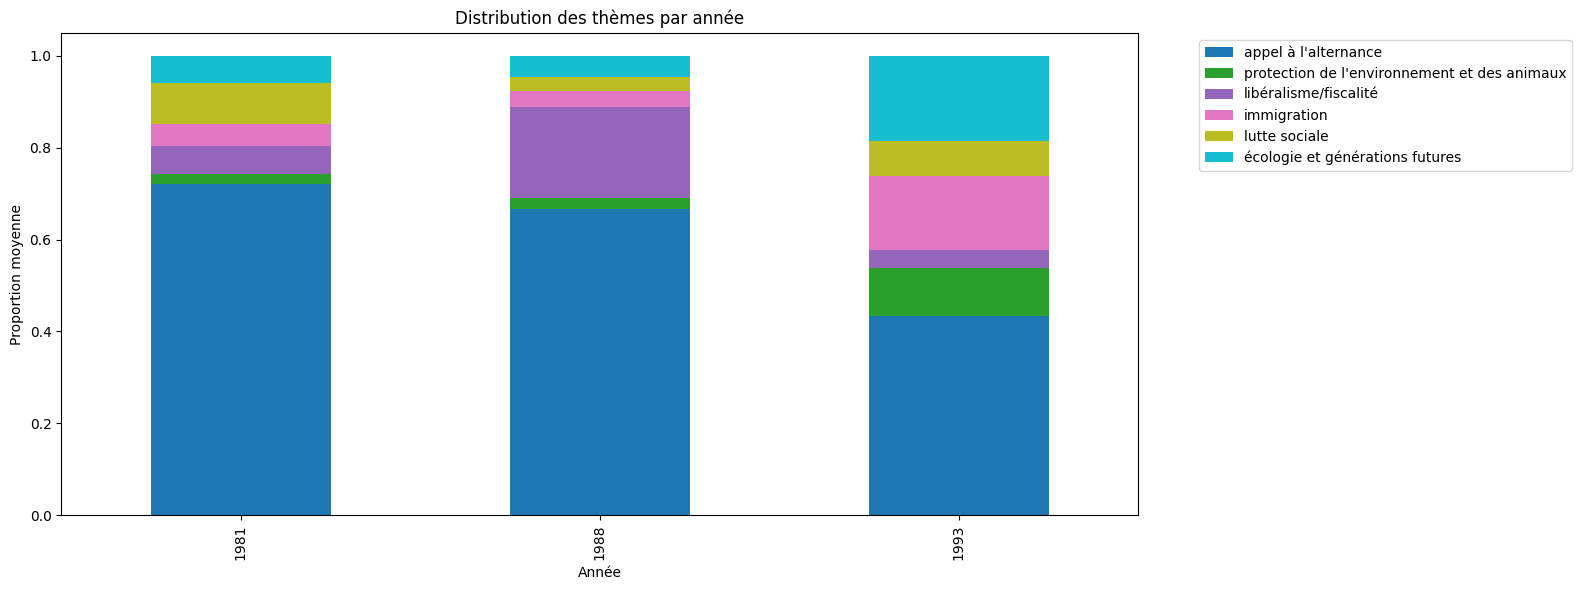

In [7]:
# topics / doc 
W_normalized = W / W.sum(axis=1, keepdims=True)

df['dominant_topic'] = np.argmax(W_normalized, axis=1)
df['dominant_label'] = df['dominant_topic'].map(topic_label)
df['topic_score']    = np.max(W_normalized, axis=1)

# topic distrib / year 
topic_cols = [f'topic_{i}' for i in range(N_TOPICS)]

# ajout colonnes
df = df.drop(columns=[col for col in df.columns if col.startswith('topic_')], errors='ignore')
W_df = pd.DataFrame(W_normalized, columns=topic_cols)
df = pd.concat([df.reset_index(drop=True), W_df], axis=1)

topic_by_year = df.groupby('annee')[topic_cols].mean()

topic_by_year.rename(
    columns={f'topic_{i}': topic_label[i] for i in range(N_TOPICS)}
).plot(
    kind='bar',
    stacked=True,
    figsize=(16, 6),
    colormap='tab10'
)
plt.title("Distribution des thèmes par année")
plt.ylabel("Proportion moyenne")
plt.xlabel("Année")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()


In [ ]:
#df.to_parquet("data/inter/df_nmf.parquet", engine="pyarrow", index=False, compression="snappy")

In [ ]:
df = pd.read_parquet("data/inter/df_lemmatized.parquet")

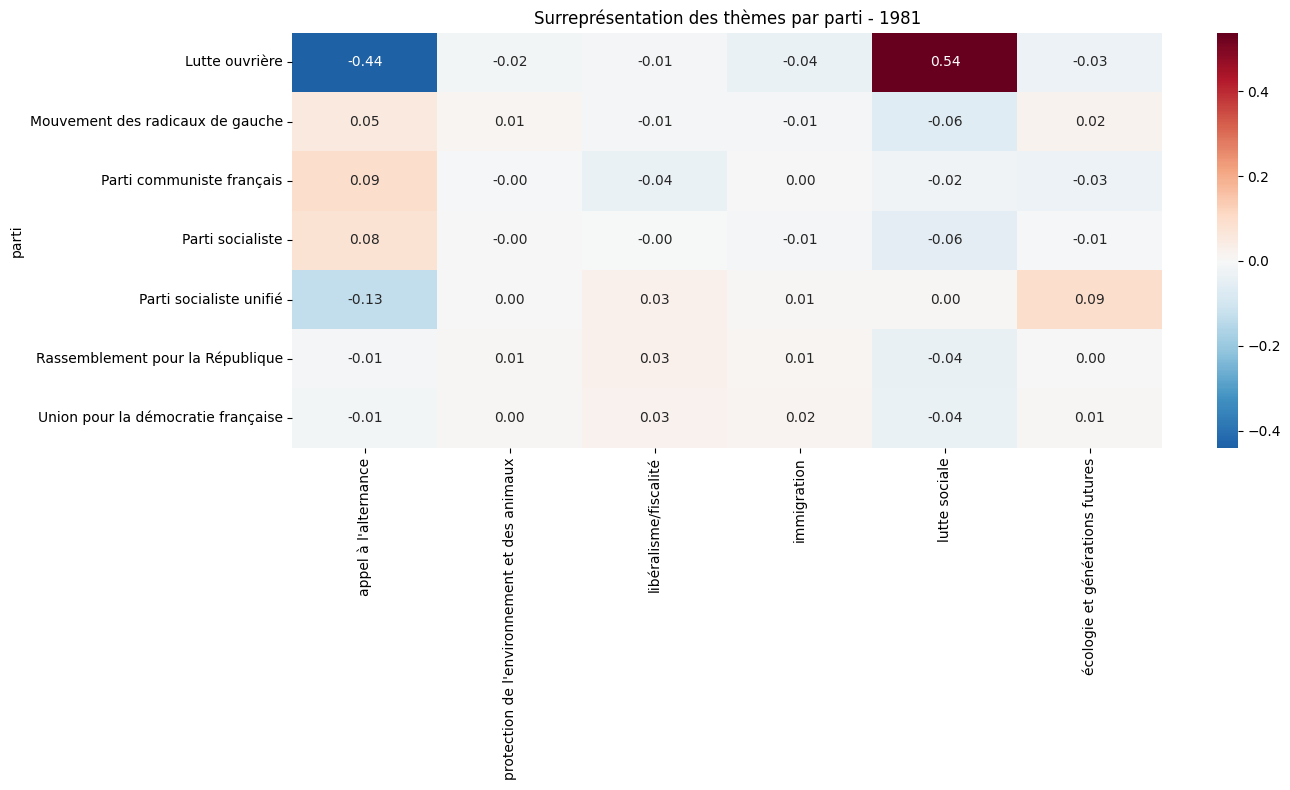

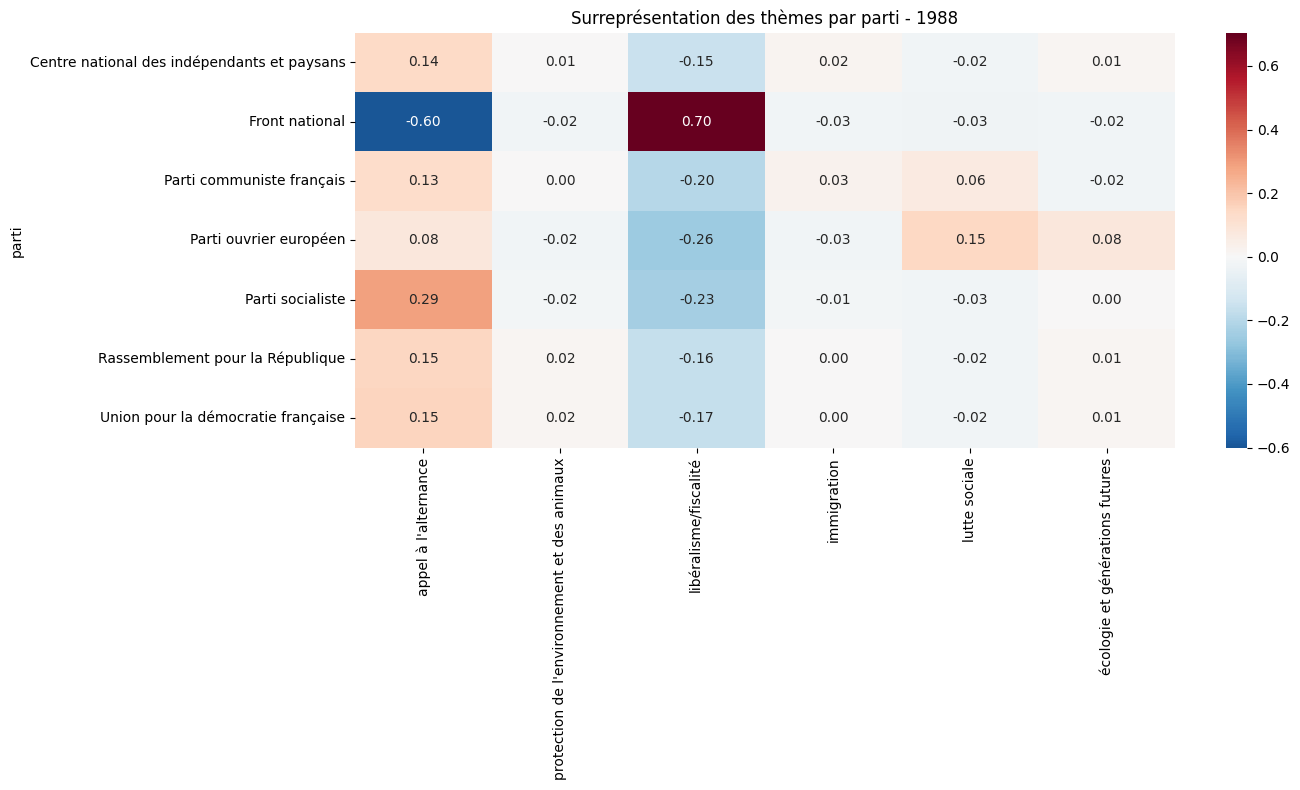

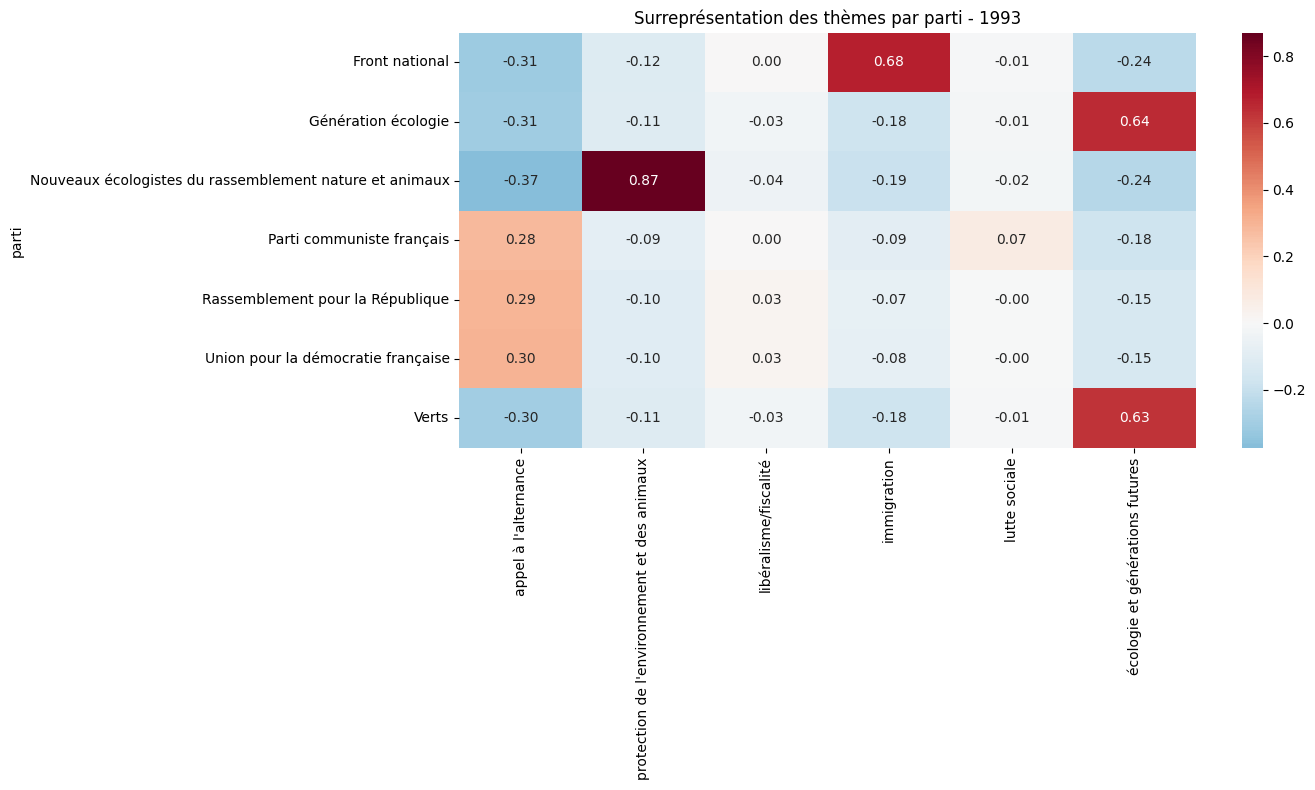

In [8]:
# créer un DataFrame explosé pour les partis
df_exploded = df.copy()
df_exploded['parti'] = df_exploded['titulaire-soutien'].str.split(';')
df_exploded = df_exploded.explode('parti')
df_exploded['parti'] = df_exploded['parti'].str.strip()
df_exploded = df_exploded[df_exploded['parti'].notna()]
df_exploded = df_exploded[df_exploded['parti'] != "non mentionné"]
df_exploded = df_exploded[df_exploded['parti'] != ""]

# boucle par année
for year, df_year in df_exploded.groupby('annee'):

    # compter les partis pour cette année et garder top nb_partis
    nb_partis = 7
    parti_counter = Counter(df_year['parti'])
    top_partis = [p for p, _ in parti_counter.most_common(nb_partis)]
    df_top = df_year[df_year['parti'].isin(top_partis)]

    # calcul surreprésentation
    global_mean = df_top[topic_cols].mean()
    topic_by_parti = df_top.groupby('parti')[topic_cols].mean()
    surreprésentation = topic_by_parti - global_mean

    # heatmap
    plt.figure(figsize=(14, 8))
    sns.heatmap(
        surreprésentation.rename(
            columns={f'topic_{i}': topic_label[i] for i in range(N_TOPICS)}
        ),
        cmap='RdBu_r',
        center=0,
        annot=True,
        fmt='.2f'
    )
    plt.title(f"Surreprésentation des thèmes par parti - {year}")
    plt.tight_layout()
    plt.show()

#### (ii) Topic modeling with embeddings : Bertopic

In [11]:
# embeddings //
#les deux ci-dessous donnent quasi exactement les mêmes résultats
#embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
embedding_model = SentenceTransformer("dangvantuan/sentence-camembert-base")


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 829.08it/s, Materializing param=pooler.dense.weight]                               
CamembertModel LOAD REPORT from: dangvantuan/sentence-camembert-base
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [12]:
docs = df['text'].tolist()

We have to consider that our texts are too long for sentence-camenbert, and the encoder must be use with texts no longer than 512 tokens 

In [ ]:
def split_text(text, chunk_size=150, overlap=30):
    words = text.split()
    chunks = []
    
    start = 0
    while start < len(words):
        end = start + chunk_size
        chunk = words[start:end]
        
        # éviter les segments trop courts
        if len(chunk) > 30:
            chunks.append(" ".join(chunk))
            
        start += chunk_size - overlap
        
    return chunks

In [ ]:
#we divide our texts using our split_function to avoid too long texts (that would be over then 512 tokens-limit)
docs_segmented = []
doc_ids = []

for i, doc in enumerate(docs):
    segments = split_text(doc)
    docs_segmented.extend(segments)
    doc_ids.extend([i] * len(segments))

In [ ]:
num_cores  = 16
chunk_size = 300
batch_size = 32
chunks = [docs_segmented[i:i+chunk_size] for i in range(0, len(docs_segmented), chunk_size)]
num_chunks = len(chunks)
print(f"Nombre total de chunks : {num_chunks}")
print(f"Embeddings générés pour {len(docs_segmented)} segments")

Nombre total de chunks : 42


In [16]:
def encode_chunk(chunk, chunk_idx):
    start      = time.time()
    embeddings = embedding_model.encode(chunk, batch_size=batch_size, convert_to_numpy=True, show_progress_bar=True)
    elapsed    = time.time() - start
    print(f"✅ Chunk {chunk_idx+1}/{num_chunks} traité en {elapsed:.2f}s")
    return embeddings, elapsed

start_total    = time.time()
results        = Parallel(n_jobs=num_cores, prefer="threads")(
    delayed(encode_chunk)(chunk, idx) for idx, chunk in enumerate(chunks)
)


embeddings     = np.vstack([res[0] for res in results])
total_time     = time.time() - start_total

print(f"\n Embeddings générés pour {len(docs)} textes")
print(f"Shape : {embeddings.shape}")
print(f"Temps total : {total_time/60:.2f} minutes")













Batches: 100%|██████████| 10/10 [01:56<00:00, 11.67s/it]



























Batches:   0%|          | 0/10 [00:00<?, ?it/s]





















































































Batches:   0%|          | 0/10 [00:00<?, ?it/s]

✅ Chunk 36/42 traité en 124.60s
































































Batches: 100%|██████████| 10/10 [02:12<00:00, 13.20s/it]A


✅ Chunk 34/42 traité en 132.45s




























Batches: 100%|██████████| 10/10 [02:05<00:00, 12.55s/it]










Batches: 100%|██████████| 10/10 [02:08<00:00, 12.89s/it]




...

✅ Chunk 38/42 traité en 61.11s



















Batches: 100%|██████████| 10/10 [00:59<00:00,  5.99s/it]


✅ Chunk 40/42 traité en 60.25s






Batches: 100%|██████████| 10/10 [01:00<00:00,  6.06s/it]











Batches: 100%|██████████| 10/10 [00:59<00:00,  5.99s/it]


✅ Chunk 39/42 traité en 61.02s
✅ Chunk 41/42 traité en 60.27s

 Embeddings générés pour 12497 textes
Shape : (12497, 768)
Temps total : 6.16 minutes


In [18]:
#nltk.download('stopwords')
STOPWORDS = stopwords.words('french')+stopwords.words('german')
STOPWORDS = list(set(STOPWORDS))

In [19]:
# UMAP : to reduce the dimensions of the embedding

umap_model = umap.UMAP(
    n_neighbors=5,
    min_dist=0.0,
    n_components=5,
    random_state=42,
    n_jobs=8
)
# hdbscan : to get clusters
hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=20,
    cluster_selection_epsilon=0.01,
    core_dist_n_jobs=8,
    prediction_data=True
)

vectorizer_model = CountVectorizer(
    stop_words=STOPWORDS,
    min_df=3
)

In [ ]:
# Bertopic

topic_model = BERTopic(
    vectorizer_model=vectorizer_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    language='french',
    nr_topics=None,
    calculate_probabilities=True,
    verbose=True
)

topics_segments, probs_segments = topic_model.fit_transform(docs_segmented, embeddings=embeddings)

#give topic to segmented docs
df_segments = pd.DataFrame({
    "doc_id": doc_ids,
    "topic": topics_segments,
    "score": probs_segments.max(axis=1)
})

# gather per document for initial/final doc
df_doc = df_segments.groupby("doc_id").agg({
    "topic": lambda x: x.value_counts().index[0],  # topic dominant par doc
    "score": "max"                                 # score max parmi les segments
}).reset_index()

# topic reduction on global dataset
# Utilisation des docs originaux pour la réduction
topic_model.reduce_topics(docs, nr_topics=10)
topics_reduced, probs_reduced = topic_model.transform(docs, embeddings=embeddings)

# final dataset
df['BERTopic_dominant'] = topics_reduced
df['BERTopic_score'] = probs_reduced.max(axis=1)

# Final check
print(topic_model.get_topic_info())


2026-04-01 10:11:47,907 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


2026-04-01 10:12:19,038 - BERTopic - Dimensionality - Completed ✓
2026-04-01 10:12:19,040 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-01 10:12:22,409 - BERTopic - Cluster - Completed ✓
2026-04-01 10:12:22,415 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-01 10:12:25,619 - BERTopic - Representation - Completed ✓
2026-04-01 10:12:27,761 - BERTopic - Topic reduction - Reducing number of topics
2026-04-01 10:12:27,771 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-01 10:12:30,987 - BERTopic - Representation - Completed ✓
2026-04-01 10:12:30,991 - BERTopic - Topic reduction - Reduced number of topics from 87 to 10
2026-04-01 10:12:31,562 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2026-04-01 10:12:31,628 - BERTopic - Dimensionality - Completed ✓
2026-04-01 10:12:31,629 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2026-04-01 10:12

   Topic  Count                                      Name  \
0     -1   5217  -1_plus_circonscription_france_politique   
1      0   5842          0_plus_france_politique_français   
2      1    538           1_national_front_vote_nationale   
3      2    396   2_animaux_nature_nouveaux_rassemblement   
4      3    239           3_patrons_leurs_maintenir_payer   
5      4     90        4_accepter_pouvons_triage_illusion   
6      5     58          5_travailleurs_parti_unité_cette   
7      6     54           6_national_front_vote_nationale   
8      7     33  7_lcr_travailleurs_revendications_contre   
9      8     30                   8_rlb_bol_ras_politique   

                                      Representation  \
0  [plus, circonscription, france, politique, tou...   
1  [plus, france, politique, français, tous, ans,...   
2  [national, front, vote, nationale, force, natu...   
3  [animaux, nature, nouveaux, rassemblement, exi...   
4  [patrons, leurs, maintenir, payer, patronat, 

In [21]:
topic_model.visualize_barchart(top_n_topics=10) 

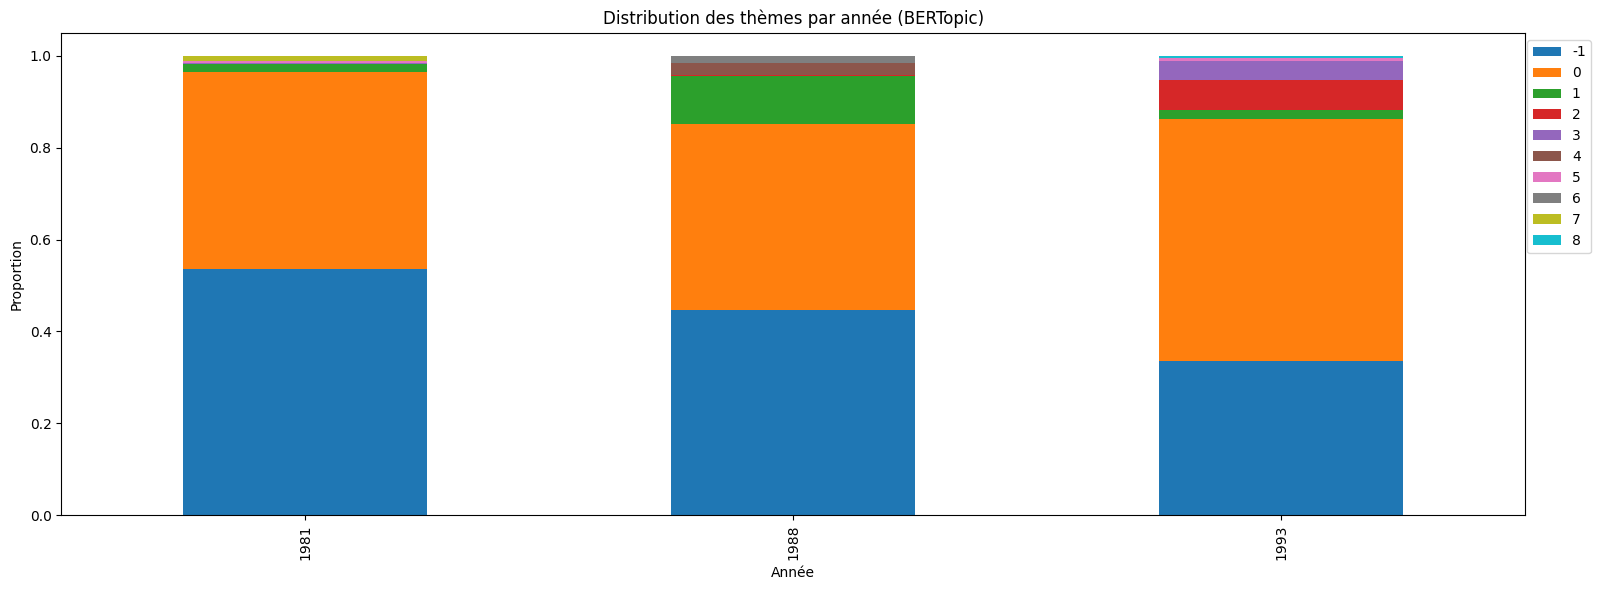

In [22]:
#distrib topic par année
topic_info = topic_model.get_topic_info().set_index('Topic')['Name'].to_dict()

topic_by_year = df.groupby(['annee', 'BERTopic_dominant']).size().unstack(fill_value=0)
topic_by_year = topic_by_year.div(topic_by_year.sum(axis=1), axis=0)  # normalisation

topic_by_year.plot(
    kind='bar',
    stacked=True,
    figsize=(16, 6),
    colormap='tab10'
)
plt.title("Distribution des thèmes par année (BERTopic)")
plt.ylabel("Proportion")
plt.xlabel("Année")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

### Restes Caroline à insérer ? 

In [14]:
meta_et_texts_metier = meta_et_texts[meta_et_texts['titulaire-profession'] != 'non mentionné']
print(meta_et_texts.shape)
print(meta_et_texts_metier.shape)

(21167, 7)
(11702, 7)


In [19]:
# On charge un modèle
import torch
torch.set_num_threads(1)
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2', device='cpu')
#model = SentenceTransformer('CATIE-AQ/camembert-base-embedding', device='cpu')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 812.12it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [22]:
# Define parameters
#chunk_size = 1000       # Chunks size to parallelize
#batch_size = 2048       # batch_size inside model
#num_cores = 8       #  Number of CPU threads to use for joblib

chunk_size = 250       # textes par chunk
batch_size = 64      # batch interne
num_cores  = 16         # processus joblib


Embedding : we transform texts into vectors of numbers ; to do so, we create chunks of texts that are transformed into number
Around 3'30

In [23]:
# put the texts together in chunks
chunks = [texts[i:i+chunk_size] for i in range(0, len(texts), chunk_size)]
num_chunks = len(chunks)

print(f"Nombre total de chunks : {num_chunks}")

# Function to encode chunk
def encode_chunk(chunk, chunk_idx):
    start = time.time()
    embeddings = model.encode(chunk, batch_size=batch_size,show_progress_bar=True, convert_to_numpy=True)
    end = time.time()
    elapsed = end - start
    print(f"✅ Chunk {chunk_idx+1}/{num_chunks} traité en {elapsed:.2f}s")
    return embeddings, elapsed


# Parallel encoding with timer
start_total = time.time()

results = Parallel(n_jobs=num_cores)(
    delayed(encode_chunk)(chunk, idx) for idx, chunk in enumerate(chunks)
)

# Séparer embeddings et temps par chunk
embeddings_list = [res[0] for res in results]
chunk_times = [res[1] for res in results]

# We put back together all the embeddings
embeddings = np.vstack(embeddings_list)
total_time = time.time() - start_total


# Some statistics on the embeddings
print(f"\nEmbeddings générés pour {len(texts)} textes")
print(f"Shape des embeddings : {embeddings.shape}")
print(f"Temps total écoulé : {total_time/60:.2f} minutes")
print(f"Temps moyen par chunk : {np.mean(chunk_times):.2f} secondes")
print(f"Temps estimé si encore {num_chunks} chunks : {np.mean(chunk_times)*(num_chunks-1)/60:.2f} minutes")

Nombre total de chunks : 47


Batches:  75%|███████▌  | 3/4 [00:11<00:03,  3.88s/it]

✅ Chunk 1/47 traité en 16.73s


Batches: 100%|██████████| 4/4 [00:15<00:00,  3.76s/it]


✅ Chunk 2/47 traité en 15.08s


...

Batches: 100%|██████████| 4/4 [00:13<00:00,  3.25s/it]


✅ Chunk 45/47 traité en 13.05s


Batches: 100%|██████████| 4/4 [00:10<00:00,  2.66s/it]


✅ Chunk 47/47 traité en 10.68s
✅ Chunk 46/47 traité en 15.97s

Embeddings générés pour 11702 textes
Shape des embeddings : (11702, 384)
Temps total écoulé : 3.27 minutes
Temps moyen par chunk : 14.21 secondes
Temps estimé si encore 47 chunks : 10.90 minutes


Batches: 100%|██████████| 4/4 [00:15<00:00,  3.98s/it]


#### Classification par thème (suite ii bis BERT caroline)

Ci-dessous, on transforme notre embedding en vecteurs de bcp plus petite dimension (environ 20 sec avec ces paramètre d'UMAP)

In [32]:
umap_embeddings = umap.UMAP(
    n_neighbors=15, min_dist=0.3, n_components=5, random_state=42, verbose = True
).fit_transform(embeddings)
print(f"UMAP embeddings shape: {umap_embeddings.shape}")

UMAP(min_dist=0.3, n_components=5, n_jobs=1, random_state=42, verbose=True)
Sat Mar 28 16:17:56 2026 Construct fuzzy simplicial set
Sat Mar 28 16:17:56 2026 Finding Nearest Neighbors
Sat Mar 28 16:17:56 2026 Building RP forest with 10 trees
Sat Mar 28 16:17:56 2026 NN descent for 14 iterations
	 1  /  14
	 2  /  14
	 3  /  14
	 4  /  14
	Stopping threshold met -- exiting after 4 iterations
Sat Mar 28 16:17:58 2026 Finished Nearest Neighbor Search
Sat Mar 28 16:17:58 2026 Construct embedding


Epochs completed:   3%| ▎          6/200 [00:00]

	completed  0  /  200 epochs


Epochs completed:  12%| █▏         23/200 [00:01]

	completed  20  /  200 epochs


...

	completed  160  /  200 epochs


Epochs completed:  92%| █████████▎ 185/200 [00:11]

	completed  180  /  200 epochs


Epochs completed: 100%| ██████████ 200/200 [00:12]


Sat Mar 28 16:18:11 2026 Finished embedding
UMAP embeddings shape: (11702, 5)


DBScan ci-dessous va créer des clusters thématiques

In [34]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=100,
                            min_samples=10,  # moins strict sur la densité
                            cluster_selection_method='leaf')
#on ajoute à notre dataframe le thème abordé par le candidat
meta_et_texts_metier['theme_cluster'] = clusterer.fit_predict(umap_embeddings)
print(f"Clusters trouvés : {meta_et_texts_metier['theme_cluster'].nunique()} (le -1 correspond aux outliers)")


Clusters trouvés : 14 (le -1 correspond aux outliers)


On essaie de labelliser les thèmes automatiquement

In [36]:
#on reliste tous les mots éliminés
all_stopwords = stopwords_fr.union(top_20_words)

# Function to get the "op words" per cluster
def get_top_words_filtered(texts, n=10):
    # put together all words in the cluster
    all_words = " ".join(texts).lower().split()
    # Remove all the words from the stowords list
    all_words = [w for w in all_words if w not in all_stopwords]
    # counting
    return Counter(all_words).most_common(n)

# Go through all clusters
for cluster_id in sorted(meta_et_texts_metier['theme_cluster'].unique()):
    if cluster_id == -1:  # ignore outliers if needed
        continue
    texts = meta_et_texts_metier[meta_et_texts_metier['theme_cluster'] == cluster_id]['texte_clean']  # utiliser la colonne filtrée
    top_words = get_top_words_filtered(texts,15)
    print(f"Cluster {cluster_id}: {top_words}")

Cluster 0: [('suppléant', 2279), ('lutte', 1403), ('progrès', 1019), ('candidats', 898), ('vote', 888), ('etat', 768), ('voter', 762), ('avertissement', 756), ('ouvrier', 642), ('révolutionnaires', 640), ('tour', 638), ('ouvriere', 630), ('ouvrière', 525), ('e', 524), ('gouvernement', 516)]
Cluster 1: [('national', 1957), ('front', 1614), ('vote', 1289), ('nationale', 1241), ('avenir', 919), ('rpr', 917), ('udf', 916), ('force', 915), ('votez', 645), ('populaire', 617), ('contre', 614), ('suppression', 614), ('convictions', 614), ('députés', 613), ('ici', 613)]
Cluster 2: [('voter', 2114), ('mitterrand', 1844), ('petits', 1483), ('contre', 1482), ('marchais', 1449), ('droite', 1271), ('lutte', 1267), ('femmes', 1065), ('travailleuses', 1056), ('gouvernement', 894), ('candidats', 855), ('hommes', 850), ('politiques', 822), ('commerçants', 813), ('ouvriere', 714)]
Cluster 3: [('voter', 1339), ('mitterrand', 1168), ('contre', 938), ('petits', 937), ('marchais', 888), ('droite', 804), ('fe

## 2/ Croisement avec les professions des candidats

@caroline pour le moment c'est ton code basé sur ton analyse des thèmes (ie. l'analyse de ii bis)
à voir quelle analyse thématique on garde et donc à adapter en conséquence

Analyse exploratoire

In [37]:
print(meta_et_texts['titulaire-profession'].nunique())
print(meta_et_texts['titulaire-profession'].value_counts())

print(meta_et_texts_metier['titulaire-profession'].nunique())
print(meta_et_texts_metier['titulaire-profession'].value_counts())

3397
titulaire-profession
non mentionné                                             9465
professeur                                                 480
avocat                                                     368
chef d'entreprise                                          234
ingénieur                                                  232
                                                          ... 
ouvrier affûteur                                             1
notaire rural;professeur droit rural Ecole de notariat       1
chirurgien Centre hospitalier                                1
travailleuse foyer                                           1
technicien gestion industrielle                              1
Name: count, Length: 3397, dtype: int64
3396
titulaire-profession
professeur                                                480
avocat                                                    368
chef d'entreprise                                         234
ingénieur                    

On a plus de 3000 professions différentes, pas vraiment d'organisation ou de nomenclature déjà déterminée ; on va donc également utiliser de l'embedding et du clustering pour attribuer aux candidats une catégorie plus vaste de métier

In [ ]:
#cleaning en préambule
professions = meta_et_texts_metier['titulaire-profession'].dropna()
professions_clean = (
    professions
    .str.lower()
    .str.strip()
    #la ligne ci-dessous permet de supprimer le point-virgule séparant les différents métiers déclarés par une même personne
    .str.replace(";", " ", regex=False) 

)
unique_professions = professions_clean.unique()

unique_professions = [clean_prof(p) for p in unique_professions]
len(unique_professions)

3383

In [39]:
#Job Embedding (2min)
model_professions = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
embeddings_professions = model_professions.encode(unique_professions,
                                                batch_size=256,
                                                show_progress_bar=True)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 888.71it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 14/14 [02:18<00:00,  9.92s/it]


In [44]:
from sklearn.cluster import KMeans

n_clusters = 12
kmeans = KMeans(n_clusters=n_clusters, random_state=42)

clusters = kmeans.fit_predict(embeddings_professions)
prof_cluster_df = pd.DataFrame({
    "profession": unique_professions,
    "cluster": clusters
})

In [53]:
cluster_map = dict(zip(prof_cluster_df.profession, prof_cluster_df.cluster))

meta_et_texts_metier["profession_clean"] = (
    meta_et_texts_metier["titulaire-profession"]
    .str.lower()
    .str.strip()
)

meta_et_texts_metier["profession_cluster"] = (
    meta_et_texts_metier["profession_clean"]
    .map(cluster_map)
)

In [54]:
#Analyse des clusters
for i in range(n_clusters):
    print("\nCluster", i)
    print(prof_cluster_df[prof_cluster_df.cluster == i].profession.tolist())


Cluster 0
['administrateur civil', 'secrétaire général entreprise', 'greffier en chef', 'cadre fonction publique territoriale', 'directeur maison de retraite', 'cadre fonction publique', 'secrétaire attachée', 'instituteur secrétaire mairie', 'président directeur général entreprise', 'administrateur centre dinformation du rock', 'directeur  développement', 'assistante parlementaire', 'secrétaire direction', 'directeur cabinet préfet', 'gérant réseau télématique du centre', 'secrétaire général', 'conseiller gestion et environnement', 'directeur bureau détudes environnement', 'ambassadeur', 'conseil entreprise directeur cabinet', 'ministère de lintérieur', 'chargée de mission sénat', 'directeur centre de tourisme', 'directeur conseiller institut de sondages', 'secrétaire mairie', 'secrétaire comptable', 'inspecteur finances directeur administration centrale', 'fonctionnaire territorial', 'directeur établissement public', 'directeur tourisme ville', 'directeur groupe communication intern

In [55]:
cluster_labels = {
0: "fct_publique_admin",
1: "commercant_cadre_commercial",
2: "medical",
3: "legal",
4: "chef_prive",
5: "education_nationale",
6: "armee_aeronautique",
7: "employes_divers",
8: "technicien",
9: "ingenieur",
10: "journaliste",
11: "agriculture"
}

On ajoute les catégories des métiers au dataframe de base

In [56]:
meta_et_texts_metier["profession_category"] = (
    meta_et_texts_metier["profession_cluster"]
    .map(cluster_labels)
)

### Analyse conjointe des sujets des professions de foi et des métiers

In [57]:
pd.crosstab(
    meta_et_texts_metier["profession_category"],
    meta_et_texts_metier["theme_cluster"],
    normalize="index"
)

theme_cluster,-1,0,1,2,3,4,5,6,7,8,9,10,11,12
profession_category,,,,,,,,,,,,,,
agriculture,0.661491,0.000000,0.055901,0.000000,0.000000,0.071429,0.012422,0.031056,0.006211,0.062112,0.006211,0.055901,0.012422,0.024845
armee_aeronautique,0.568182,0.005682,0.119318,0.005682,0.000000,0.034091,0.000000,0.017045,0.005682,0.056818,0.011364,0.119318,0.000000,0.056818
chef_prive,0.655324,0.014270,0.050494,0.004391,0.001098,0.045005,0.013172,0.010977,0.015368,0.076839,0.010977,0.071350,0.007684,0.023052
commercant_cadre_commercial,0.605313,0.022138,0.021505,0.022138,0.039216,0.064516,0.008855,0.028463,0.007590,0.080961,0.027830,0.033523,0.008223,0.029728
education_nationale,0.688517,0.000493,0.011828,0.009857,0.013800,0.072942,0.006900,0.030064,0.018728,0.056678,0.024150,0.018236,0.012814,0.034993
employes_divers,0.612210,0.035254,0.019776,0.058469,0.009458,0.039553,0.014617,0.019776,0.015477,0.079966,0.026655,0.029235,0.010318,0.029235
fct_publique_admin,0.688253,0.003012,0.030120,0.000000,0.004518,0.055723,0.006024,0.013554,0.019578,0.084337,0.012048,0.034639,0.009036,0.039157
ingenieur,0.609489,0.009124,0.036496,0.018248,0.001825,0.096715,0.009124,0.025547,0.014599,0.087591,0.014599,0.043796,0.009124,0.023723
journaliste,0.653226,0.004032,0.048387,0.000000,0.004032,0.060484,0.032258,0.020161,0.016129,0.056452,0.024194,0.032258,0.008065,0.040323


11 est une catégorie qui a l'air très "fourre-tout", on a clairement pas un résultat fou

##### Visualisation

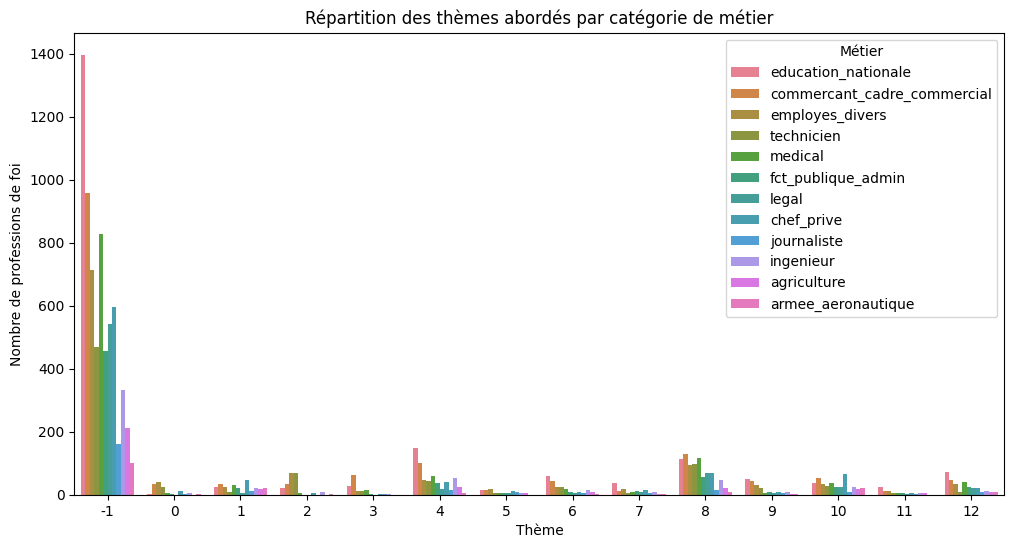

In [59]:
plt.figure(figsize=(12,6))
sns.countplot(x='theme_cluster', hue='profession_category', data=meta_et_texts_metier)
plt.title("Répartition des thèmes abordés par catégorie de métier")
plt.xlabel("Thème")
plt.ylabel("Nombre de professions de foi")
plt.legend(title="Métier")
plt.show()

## Analyses statistiques diverses

In [61]:
contingency_table = pd.crosstab(meta_et_texts_metier['profession_category'], meta_et_texts_metier['theme_cluster'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi2 = {chi2:.2f}, p-value = {p:.4f}")

Chi2 = 1069.49, p-value = 0.0000
